# 03 — Explore data quality

Inspect a few contrasting sensors before designing the cleaning rule: PM2.5 distribution (negatives, impossible highs), A/B channel agreement (the fault signal), time gaps, and temperature/humidity completeness. Saves the histogram and A/B-agreement figures used later.

In [20]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # so `from src...` works from notebooks/
from src.config import *
import pandas as pd
import matplotlib.pyplot as plt

# contrasting sensors: SL001 healthy/long, SL026 mid, SL030 sparse
samples = ["SL001_Sunnyview_Terrace", "SL026", "SL030"]

dfs = {}
for s in samples:
    dfs[s] = pd.read_parquet(PROCESSED / f"{s}.parquet")
    print(f"{s}: {len(dfs[s]):,} rows, "
          f"{dfs[s][DATE_COL].min()} -> {dfs[s][DATE_COL].max()}")

SL001_Sunnyview_Terrace: 1,038,078 rows, 2022-03-07 18:37:08+00:00 -> 2026-02-19 18:57:20+00:00
SL026: 932,711 rows, 2022-03-25 14:31:32+00:00 -> 2026-06-29 23:58:58+00:00
SL030: 12,491 rows, 2022-03-25 14:40:07+00:00 -> 2023-04-08 23:50:21+00:00


### PM2.5 distribution: negatives and impossible highs

In [21]:
for s, df in dfs.items():
    a = df[PM_A]
    print(f"\n=== {s} ===")
    print(f"  min: {a.min():.1f}   max: {a.max():.1f}   median: {a.median():.1f}")
    print(f"  negatives: {(a < 0).sum():,}")
    print(f"  exactly zero: {(a == 0).sum():,}")
    print(f"  above 500 (suspicious): {(a > 500).sum():,}")
    print(f"  NaN: {a.isna().sum():,}")


=== SL001_Sunnyview_Terrace ===
  min: 0.0   max: 3402.1   median: 2.9
  negatives: 0
  exactly zero: 323,439
  above 500 (suspicious): 173,246
  NaN: 0

=== SL026 ===
  min: 0.0   max: 409.5   median: 1.9
  negatives: 0
  exactly zero: 284,785
  above 500 (suspicious): 0
  NaN: 0

=== SL030 ===
  min: 0.0   max: 72.6   median: 0.1
  negatives: 0
  exactly zero: 6,048
  above 500 (suspicious): 0
  NaN: 0


### Histogram of PM2.5 (clipped at 60 so outliers don't hide the shape)

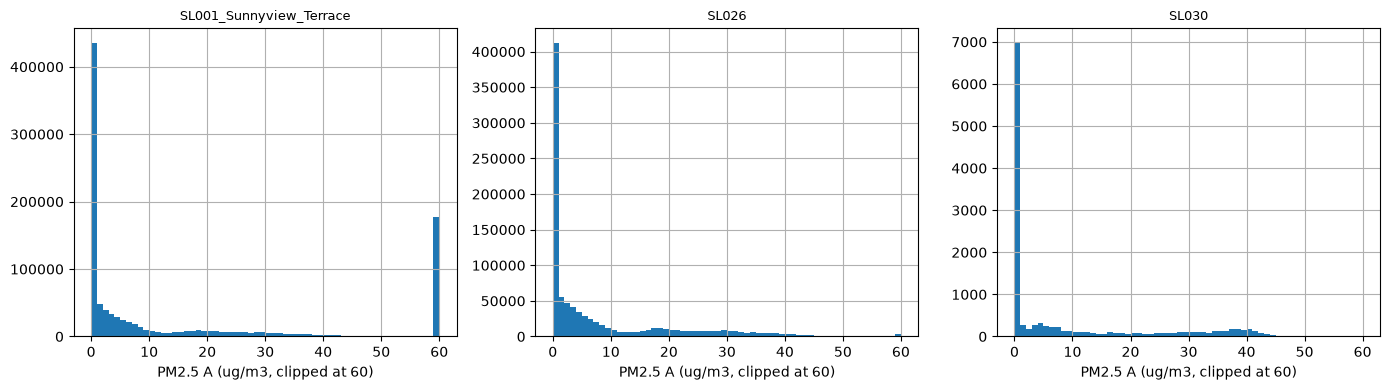

In [22]:
fig, axes = plt.subplots(1, len(samples), figsize=(14, 4))
for ax, (s, df) in zip(axes, dfs.items()):
    df[PM_A].clip(0, 60).hist(bins=60, ax=ax)
    ax.set_title(s, fontsize=9)
    ax.set_xlabel("PM2.5 A (ug/m3, clipped at 60)")
plt.tight_layout()
plt.savefig(OUT_FIGURES / "pm25_histograms.png", dpi=150)
plt.show()

### A vs B channel agreement — the fault signal
A healthy sensor's points hug the diagonal; a faulty one sprays off it.

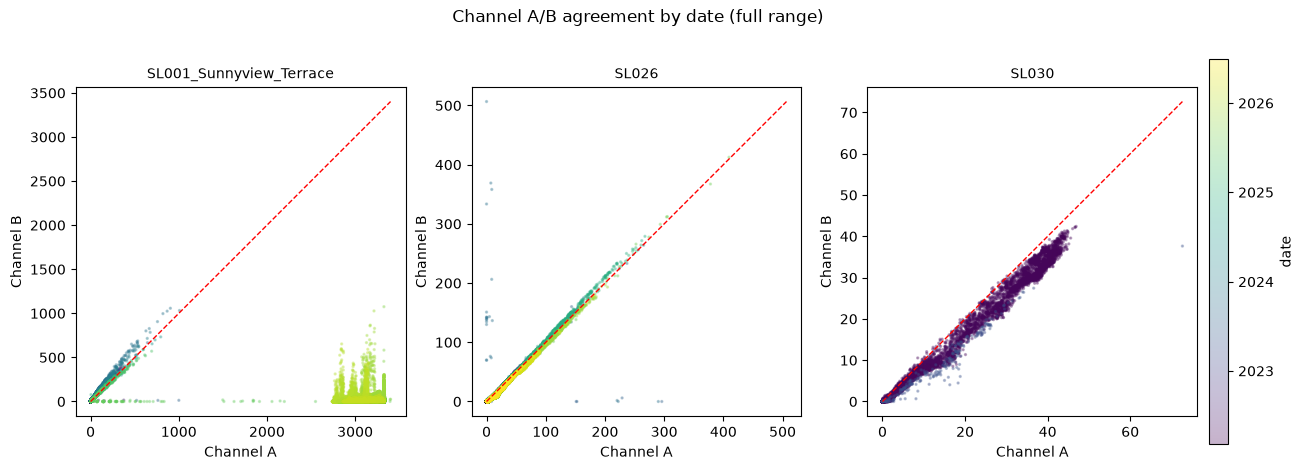

SL001_Sunnyview_Terrace: median |A-B| = 1.28, 95th pct = 3325.10, max = 3395.9
SL026: median |A-B| = 1.24, 95th pct = 5.30, max = 506.6
SL030: median |A-B| = 0.06, 95th pct = 6.32, max = 35.0


In [23]:
import matplotlib.dates as mdates
import numpy as np
fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))

# shared date range so the one colourbar is honest across panels
allmin = min(df[DATE_COL].min() for df in dfs.values())
allmax = max(df[DATE_COL].max() for df in dfs.values())
vmin, vmax = mdates.date2num(allmin), mdates.date2num(allmax)

for ax, (s, df) in zip(axes, dfs.items()):
    sub = df[[DATE_COL, PM_A, PM_B]].dropna()
    sc = ax.scatter(sub[PM_A], sub[PM_B],                 # no .clip — full range
                    c=mdates.date2num(sub[DATE_COL]), cmap="viridis",
                    s=2, alpha=0.3, vmin=vmin, vmax=vmax)

    # diagonal spanning each panel's own range
    hi = max(sub[PM_A].max(), sub[PM_B].max())
    ax.plot([0, hi], [0, hi], "r--", lw=1)
    ax.set_title(s, fontsize=10)
    ax.set_xlabel("Channel A"); ax.set_ylabel("Channel B")
    ax.set_aspect("equal")                                # auto-scales to real data

cbar = fig.colorbar(sc, ax=axes.tolist(), fraction=0.025, pad=0.01)
cbar.ax.set_ylabel("date", rotation=90)
yl = mdates.YearLocator()
cbar.ax.yaxis.set_major_locator(yl)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.suptitle("Channel A/B agreement by date (full range)", fontsize=12)
fig.savefig(OUT_FIGURES / "channel_AB_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

# numeric summary, unchanged
for s, df in dfs.items():
    diff = (df[PM_A] - df[PM_B]).abs()
    print(f"{s}: median |A-B| = {diff.median():.2f}, "
          f"95th pct = {diff.quantile(0.95):.2f}, max = {diff.max():.1f}")

### Time gaps between readings

In [24]:
for s, df in dfs.items():
    gaps = df[DATE_COL].diff().dt.total_seconds() / 60   # minutes
    print(f"\n=== {s} ===")
    print(f"  median gap: {gaps.median():.1f} min  (expected ~2)")
    print(f"  gaps > 10 min: {(gaps > 10).sum():,}")
    print(f"  gaps > 1 day: {(gaps > 1440).sum():,}  (offline stretches)")


=== SL001_Sunnyview_Terrace ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 61
  gaps > 1 day: 1  (offline stretches)

=== SL026 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 174
  gaps > 1 day: 5  (offline stretches)

=== SL030 ===
  median gap: 2.0 min  (expected ~2)
  gaps > 10 min: 118
  gaps > 1 day: 7  (offline stretches)


### Temperature & humidity completeness
Relevant because the humidity correction (next stage) needs RH present.

In [25]:
for s, df in dfs.items():
    print(f"{s}: Temp missing {df[TEMP_COL].isna().mean()*100:.1f}%, "
          f"Humidity missing {df[RH_COL].isna().mean()*100:.1f}%")

SL001_Sunnyview_Terrace: Temp missing 23.5%, Humidity missing 23.5%
SL026: Temp missing 0.0%, Humidity missing 0.0%
SL030: Temp missing 0.0%, Humidity missing 0.0%
